In [1]:
import pandas as pd

df = pd.read_csv('D:/project/customer segmentation/data/customer_data.csv')

In [2]:
print(df.shape)
print(df.head())
print(df.info())

(10000, 19)
  customer_id   age location  tenure  orders  total_spend  avg_order_value  \
0  CUST_00001  19.0     Pune     7.0      21     28068.63          1336.60   
1  CUST_00002  23.0   Mumbai     0.8      10     12724.65          1272.47   
2  CUST_00003  38.0    Delhi     0.4       6      7685.84          1280.97   
3  CUST_00004  22.0     Pune     3.1       8      8399.66          1049.96   
4  CUST_00005  45.0  Chennai     3.6      27     77924.19          2886.08   

   purchase_frequency  days_since_last_purchase  discount_usage  returns  \
0                3.00                        30           0.275        0   
1               12.50                       127           0.482        2   
2               15.00                        79           0.343        1   
3                2.58                        16           0.643        4   
4                7.50                        27           0.101        1   

   product_categories  website_visits  app_sessions  email_int

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate customer IDs:")
print(df["customer_id"].duplicated().sum())

Missing values:
customer_id                   0
age                         100
location                      0
tenure                      100
orders                        0
total_spend                   0
avg_order_value             100
purchase_frequency            0
days_since_last_purchase      0
discount_usage                0
returns                       0
product_categories            0
website_visits              100
app_sessions                  0
email_interaction           100
cart_additions                0
cart_abandonment              0
wishlist_activity             0
support_interactions          0
dtype: int64

Missing percentage:
customer_id                 0.0
age                         1.0
location                    0.0
tenure                      1.0
orders                      0.0
total_spend                 0.0
avg_order_value             1.0
purchase_frequency          0.0
days_since_last_purchase    0.0
discount_usage              0.0
returns               

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,9900.0,34.372020,9.495299,18.00,27.0000,34.0000,41.0000,70.000
tenure,9900.0,3.271616,2.156956,0.20,1.6000,2.8000,4.4000,10.000
orders,10000.0,14.015000,8.715364,1.00,7.0000,13.0000,21.0000,76.000
total_spend,10000.0,26466.976549,20719.028040,250.00,8679.0975,18689.5700,43172.6425,144683.940
avg_order_value,9900.0,1758.840325,648.120121,250.00,1275.3300,1697.9750,2165.3900,4098.850
purchase_frequency,10000.0,7.502106,10.694445,0.10,2.0600,4.3800,8.7000,165.000
days_since_last_purchase,10000.0,46.305000,55.037215,1.00,10.0000,24.0000,61.2500,365.000
discount_usage,10000.0,0.420033,0.243389,0.01,0.2270,0.3765,0.5820,0.997
returns,10000.0,1.473300,1.364725,0.00,0.0000,1.0000,2.0000,10.000
product_categories,10000.0,3.546000,1.484892,1.00,2.7500,4.0000,5.0000,9.000


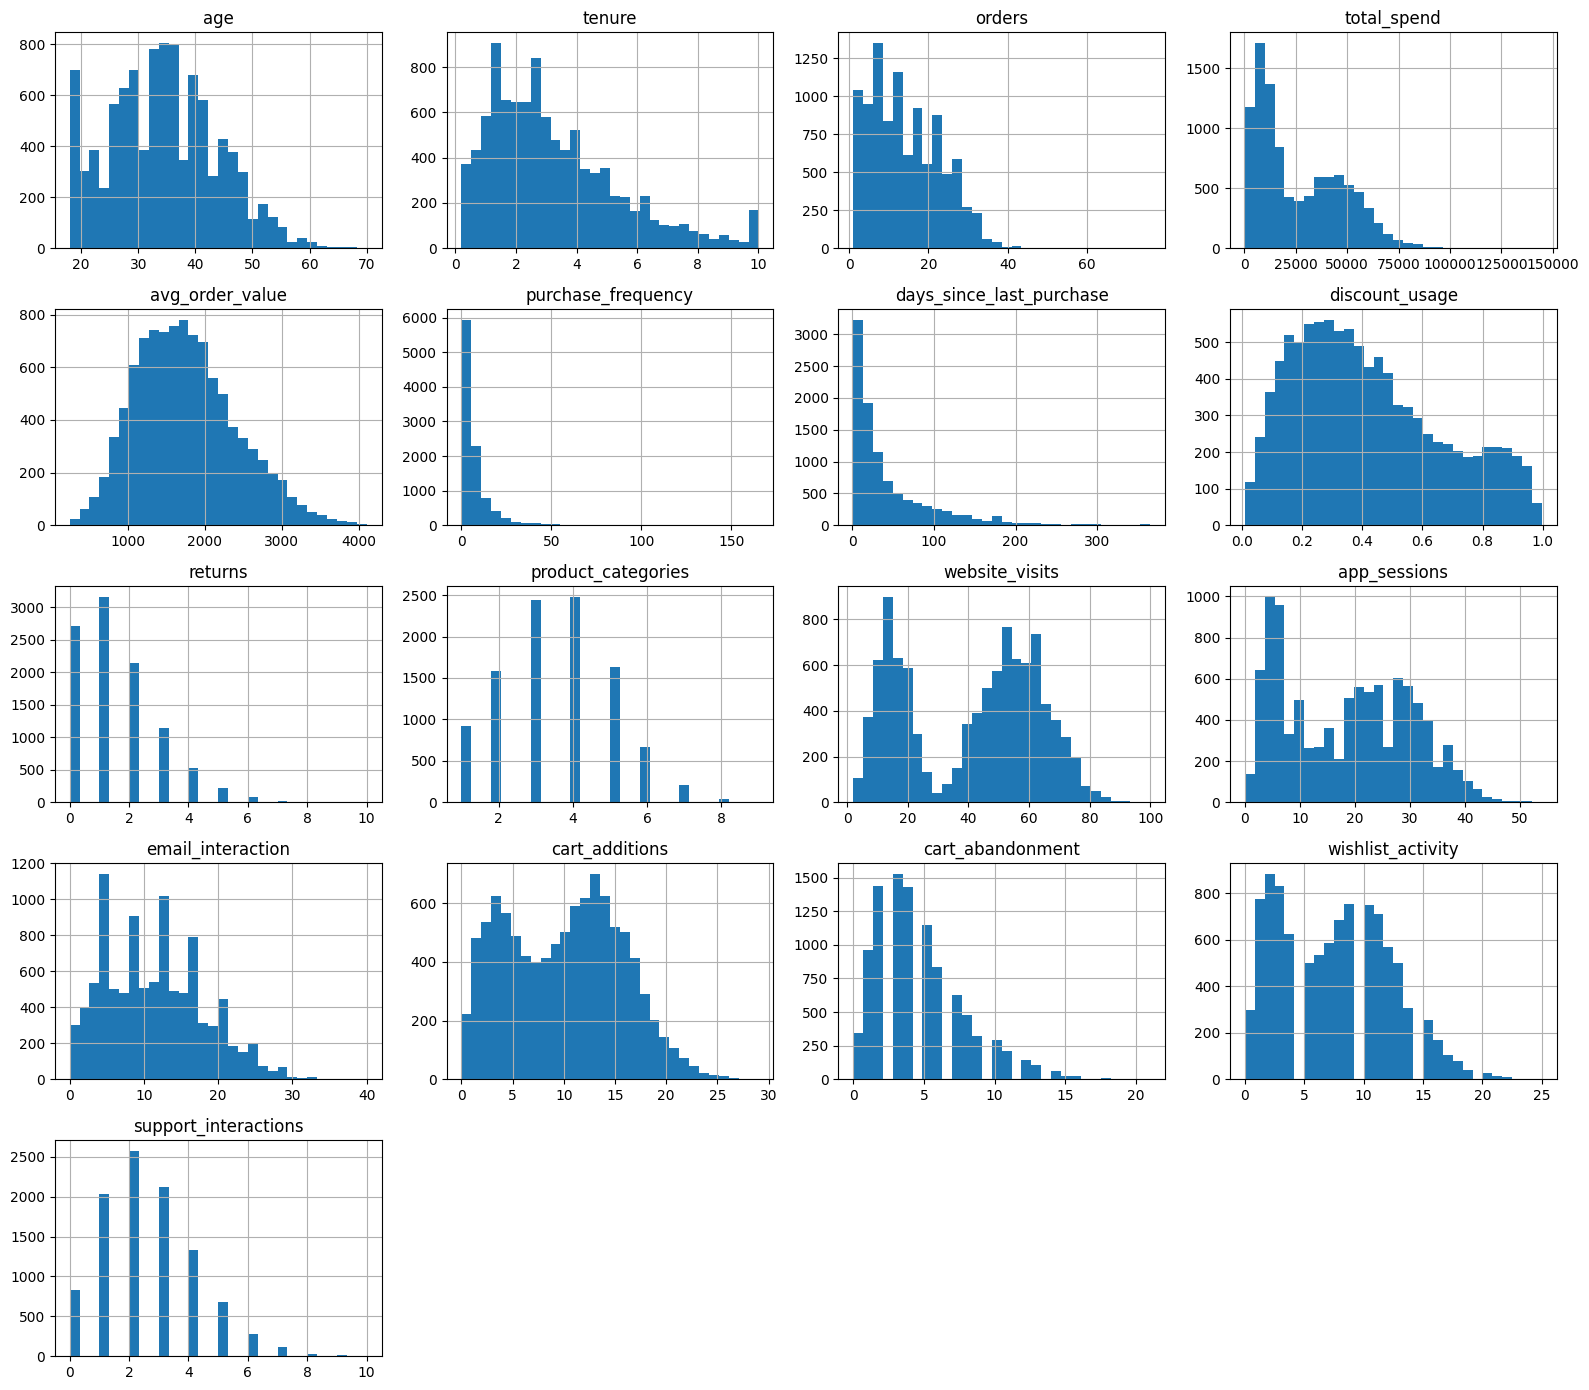

In [5]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(16, 14),
    bins=30
)

plt.tight_layout()
plt.show()

In [6]:
df.nlargest(10, "purchase_frequency")[
    ["customer_id", "orders", "tenure", "purchase_frequency", "total_spend"]
]

,customer_id,orders,tenure,purchase_frequency,total_spend
9686,CUST_09687,33,0.2,165.0,68928.71
7254,CUST_07255,32,0.2,160.0,70687.12
3140,CUST_03141,30,0.2,150.0,47856.22
4750,CUST_04751,29,0.2,145.0,40406.60
8036,CUST_08037,27,0.2,135.0,68547.91
3533,CUST_03534,25,0.2,125.0,39089.65
9473,CUST_09474,25,0.2,125.0,42140.92
3548,CUST_03549,24,0.2,120.0,37307.14
4544,CUST_04545,24,0.2,120.0,43877.82
7491,CUST_07492,24,0.2,120.0,49170.15


In [7]:
df.nlargest(10, "total_spend")[
    ["customer_id", "orders", "tenure",
     "avg_order_value", "total_spend"]
]

,customer_id,orders,tenure,avg_order_value,total_spend
7325,CUST_07326,42,3.6,3444.855714,144683.94
8067,CUST_08068,72,2.2,1895.515278,136477.10
5190,CUST_05191,76,4.0,1746.974211,132770.04
2685,CUST_02686,42,3.4,3020.965714,126880.56
5197,CUST_05198,36,1.8,3348.020000,120528.72
7992,CUST_07993,48,3.6,2325.239167,111611.48
377,CUST_00378,29,8.1,3558.850000,103206.68
1723,CUST_01724,25,1.4,4068.960000,101723.97
6452,CUST_06453,36,3.4,2806.810000,101045.26
3286,CUST_03287,43,0.7,2276.150000,97874.40


In [8]:
df_clean = df.copy()

In [9]:
numeric_missing_cols = [
    "age",
    "tenure",
    "avg_order_value",
    "website_visits",
    "email_interaction"
]

for col in numeric_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [10]:
df_clean[numeric_missing_cols].isnull().sum()

age                  0
tenure               0
avg_order_value      0
website_visits       0
email_interaction    0
dtype: int64

In [11]:
df_clean["recency"] = df_clean["days_since_last_purchase"]

df_clean["frequency"] = (
    df_clean["orders"] / df_clean["tenure"]
)

df_clean["monetary_value"] = df_clean["total_spend"]

df_clean["discount_dependency"] = df_clean["discount_usage"]

In [12]:
engagement_cols = [
    "website_visits",
    "app_sessions",
    "email_interaction",
    "wishlist_activity"
]

In [13]:
df_clean[
    ["recency", "frequency", "monetary_value", "discount_dependency"]
].describe()

,recency,frequency,monetary_value,discount_dependency
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,46.305000,7.488687,26466.976549,0.420033
std,55.037215,10.662964,20719.028040,0.243389
min,1.000000,0.100000,250.000000,0.010000
25%,10.000000,2.068966,8679.097500,0.227000
50%,24.000000,4.375000,18689.570000,0.376500
75%,61.250000,8.695652,43172.642500,0.582000
max,365.000000,165.000000,144683.940000,0.997000


In [14]:
from sklearn.preprocessing import MinMaxScaler

engagement_cols = [
    "website_visits",
    "app_sessions",
    "email_interaction",
    "wishlist_activity"
]

engagement_scaler = MinMaxScaler()

df_clean[engagement_cols] = engagement_scaler.fit_transform(
    df_clean[engagement_cols]
)

df_clean["engagement_score"] = df_clean[engagement_cols].mean(axis=1)

In [15]:
df_clean["engagement_score"].describe()

count    10000.000000
mean         0.328616
std          0.169433
min          0.009732
25%          0.138452
50%          0.404608
75%          0.466142
max          0.647342
Name: engagement_score, dtype: float64

In [16]:
corr = df_clean.select_dtypes(include="number").corr()

corr["total_spend"].sort_values(ascending=False)

total_spend                 1.000000
monetary_value              1.000000
orders                      0.878669
app_sessions                0.710419
website_visits              0.691988
avg_order_value             0.687859
engagement_score            0.602921
cart_additions              0.498930
frequency                   0.377832
purchase_frequency          0.373735
wishlist_activity           0.368738
email_interaction           0.210967
age                         0.013773
support_interactions        0.009478
tenure                      0.007719
product_categories         -0.004684
returns                    -0.083069
cart_abandonment           -0.296070
recency                    -0.439306
days_since_last_purchase   -0.439306
discount_usage             -0.495273
discount_dependency        -0.495273
Name: total_spend, dtype: float64

In [17]:
df_clean[["frequency", "purchase_frequency"]].corr()

,frequency,purchase_frequency
frequency,1.000000,0.995807
purchase_frequency,0.995807,1.000000


In [18]:
features_for_corr = [
    "age",
    "tenure",
    "frequency",
    "monetary_value",
    "avg_order_value",
    "recency",
    "returns",
    "product_categories",
    "engagement_score",
    "discount_dependency",
    "cart_additions",
    "cart_abandonment",
    "support_interactions"
]

df_clean[features_for_corr].corr()

,age,tenure,frequency,monetary_value,avg_order_value,recency,returns,product_categories,engagement_score,discount_dependency,cart_additions,cart_abandonment,support_interactions
age,1.000000,-0.005747,0.005735,0.013773,0.017832,-0.006803,0.003683,0.007358,0.008827,0.014943,0.012024,0.014329,-0.001630
tenure,-0.005747,1.000000,-0.456573,0.007719,0.007411,-0.016202,0.003624,-0.000592,0.024830,-0.001857,0.021836,0.007387,-0.001316
frequency,0.005735,-0.456573,1.000000,0.377832,0.149545,-0.193574,0.015202,0.000419,0.290586,-0.150686,0.240124,-0.085195,-0.000442
monetary_value,0.013773,0.007719,0.377832,1.000000,0.687859,-0.439306,-0.083069,-0.004684,0.602921,-0.495273,0.498930,-0.296070,0.009478
avg_order_value,0.017832,0.007411,0.149545,0.687859,1.000000,-0.175933,-0.196988,0.003902,0.174047,-0.534063,0.105739,-0.398021,0.010211
recency,-0.006803,-0.016202,-0.193574,-0.439306,-0.175933,1.000000,0.004377,-0.003104,-0.683794,0.165033,-0.602738,-0.160202,-0.004394
returns,0.003683,0.003624,0.015202,-0.083069,-0.196988,0.004377,1.000000,0.005418,0.115983,0.304335,0.088154,0.197501,-0.025341
product_categories,0.007358,-0.000592,0.000419,-0.004684,0.003902,-0.003104,0.005418,1.000000,0.002851,-0.004696,-0.002719,0.006557,0.010721
engagement_score,0.008827,0.024830,0.290586,0.602921,0.174047,-0.683794,0.115983,0.002851,1.000000,-0.077306,0.804787,0.206006,0.013349
discount_dependency,0.014943,-0.001857,-0.150686,-0.495273,-0.534063,0.165033,0.304335,-0.004696,-0.077306,1.000000,-0.069163,0.476345,-0.019227


In [19]:
clustering_features = [
    "age",
    "tenure",
    "frequency",
    "monetary_value",
    "avg_order_value",
    "recency",
    "returns",
    "product_categories",
    "engagement_score",
    "discount_dependency",
    "cart_additions",
    "cart_abandonment",
    "support_interactions"
]

In [20]:
X = df_clean[clustering_features]

X.shape

(10000, 13)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(10000, 13)

In [22]:
X_scaled[:5]

array([[-1.62674012e+00,  1.73911711e+00, -4.20981636e-01,
         7.73073687e-02, -6.53827085e-01, -2.96268901e-01,
        -1.07961242e+00,  3.05761414e-01,  1.47340263e+00,
        -5.95918537e-01,  7.13050790e-01,  1.18885318e-01,
        -3.18108937e-01],
       [-1.20333867e+00, -1.14924004e+00,  4.69997205e-01,
        -6.63303978e-01, -7.53273910e-01,  1.46626304e+00,
         3.85957958e-01,  3.05761414e-01, -1.82034590e+00,
         2.54614737e-01, -1.53364939e+00, -5.20454924e-01,
         3.11186685e-01],
       [ 3.84416759e-01, -1.33558566e+00,  7.04465321e-01,
        -9.06513358e-01, -7.40092902e-01,  5.94082288e-01,
        -3.46827229e-01,  3.05761414e-01, -1.23502718e+00,
        -3.16516302e-01, -4.96710845e-01,  4.38555439e-01,
         9.40482308e-01],
       [-1.30918903e+00, -7.77527110e-02, -4.60311772e-01,
        -8.72059247e-01, -1.09832167e+00, -5.50654954e-01,
         1.85152833e+00,  3.05761414e-01,  7.42901858e-02,
         9.16140617e-01,  2.17584271e

In [23]:
from sklearn.decomposition import PCA

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

pca_full.explained_variance_ratio_

array([0.25434132, 0.17074257, 0.10657446, 0.07790319, 0.07721433,
       0.07595578, 0.06892683, 0.041456  , 0.03893098, 0.03333836,
       0.02943134, 0.01524401, 0.00994082])

In [24]:
pca_full.explained_variance_ratio_.cumsum()

array([0.25434132, 0.42508389, 0.53165836, 0.60956155, 0.68677588,
       0.76273166, 0.83165849, 0.87311449, 0.91204547, 0.94538383,
       0.97481517, 0.99005918, 1.        ])

In [25]:
pca = PCA(n_components=8)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(10000, 8)

In [26]:
pca.explained_variance_ratio_.sum()

np.float64(0.8731144893874067)

In [28]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

inertias

[85464.65760838185,
 68430.53955096124,
 63746.35699993659,
 60554.32194476765,
 57845.383820042545,
 55933.00255295227,
 54131.02173000505,
 52429.09803682005,
 51017.83048173523]

In [29]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_pca)
    
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.2412779399369354,
 0.28171039375311696,
 0.23024330131392406,
 0.16973005658036783,
 0.14957392266045155,
 0.14683840485219624,
 0.13672780951992283,
 0.13534457836948854,
 0.13402241554879707]

In [30]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_pca)

In [31]:
df_clean["cluster"] = cluster_labels

df_clean["cluster"].value_counts().sort_index()

cluster
0    4405
1    1909
2    3686
Name: count, dtype: int64

In [32]:
profile_features = [
    "age",
    "tenure",
    "frequency",
    "monetary_value",
    "avg_order_value",
    "recency",
    "returns",
    "product_categories",
    "engagement_score",
    "discount_dependency",
    "cart_additions",
    "cart_abandonment",
    "support_interactions"
]

cluster_profile = df_clean.groupby("cluster")[profile_features].mean()

cluster_profile

,age,tenure,frequency,monetary_value,avg_order_value,recency,returns,product_categories,engagement_score,discount_dependency,cart_additions,cart_abandonment,support_interactions
cluster,,,,,,,,,,,,,
0,34.461521,3.286470,11.681600,46549.296365,2183.692706,13.061748,1.235868,3.540749,0.457708,0.250582,13.616118,3.457435,2.541657
1,34.468308,3.314772,5.740252,12509.226574,1113.301587,29.156103,2.550026,3.569932,0.438010,0.781194,13.003667,8.927187,2.448926
2,34.205100,3.218719,3.383420,9696.147984,1583.792082,94.914270,1.199403,3.539881,0.117687,0.435490,3.781335,3.800597,2.491590


In [33]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(X_pca, cluster_labels)
davies_bouldin = davies_bouldin_score(X_pca, cluster_labels)
calinski_harabasz = calinski_harabasz_score(X_pca, cluster_labels)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", davies_bouldin)
print("Calinski-Harabasz Score:", calinski_harabasz)

Silhouette Score: 0.28171039375311696
Davies-Bouldin Score: 1.3205613218544856
Calinski-Harabasz Score: 3292.450185329405


In [34]:
min_samples = 5

In [35]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_pca)

distances, indices = neighbors.kneighbors(X_pca)

k_distances = np.sort(distances[:, -1])

k_distances[-20:]

array([2.7919005 , 2.79331787, 2.8384869 , 2.86695786, 2.87904502,
       2.90626352, 2.91741538, 2.98743306, 2.99082308, 3.00338254,
       3.05940381, 3.06035727, 3.1189499 , 3.20156756, 3.37337196,
       3.53755518, 3.58528812, 3.77579911, 3.85856777, 3.87518834])

In [36]:
from sklearn.cluster import DBSCAN

for eps in [3.0, 3.2, 3.4, 3.6, 3.8]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=3.0 | clusters=1 | noise=3
eps=3.2 | clusters=1 | noise=1
eps=3.4 | clusters=1 | noise=0
eps=3.6 | clusters=1 | noise=0
eps=3.8 | clusters=1 | noise=0


In [37]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

X_pca_2d.shape

(10000, 2)

In [38]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_pca_2d)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=0.3 | clusters=1 | noise=54
eps=0.5 | clusters=1 | noise=13
eps=0.7 | clusters=1 | noise=2
eps=1.0 | clusters=1 | noise=0


In [39]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg.fit_predict(X_pca)

df_clean["agg_cluster"] = agg_labels

df_clean["agg_cluster"].value_counts().sort_index()

agg_cluster
0    4457
1    3695
2    1848
Name: count, dtype: int64

In [40]:
agg_silhouette = silhouette_score(X_pca, agg_labels)
agg_davies_bouldin = davies_bouldin_score(X_pca, agg_labels)
agg_calinski = calinski_harabasz_score(X_pca, agg_labels)

print("Silhouette Score:", agg_silhouette)
print("Davies-Bouldin Score:", agg_davies_bouldin)
print("Calinski-Harabasz Score:", agg_calinski)

Silhouette Score: 0.28093586511645297
Davies-Bouldin Score: 1.3233137180523495
Calinski-Harabasz Score: 3266.144245447506


In [41]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

In [42]:
df_clean["PC1"] = X_pca_2d[:, 0]
df_clean["PC2"] = X_pca_2d[:, 1]

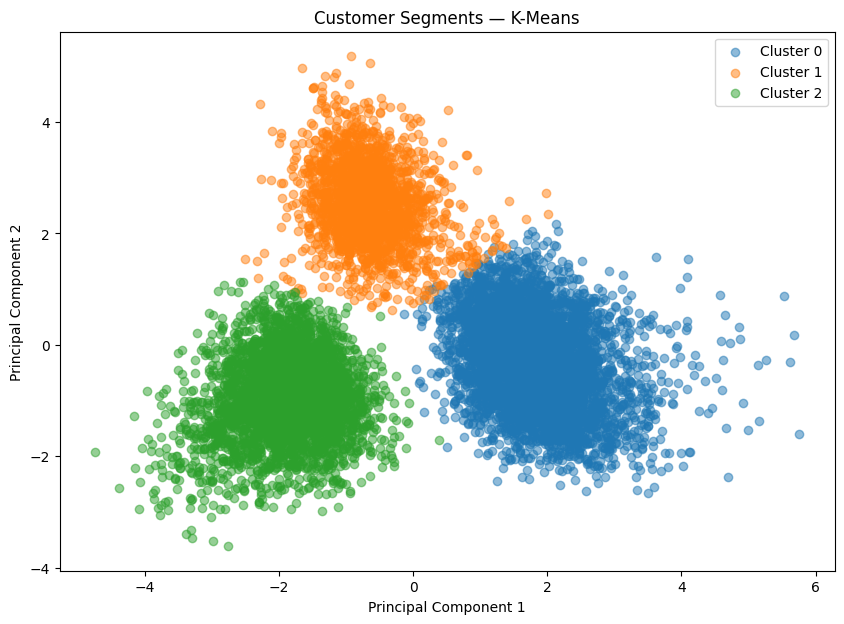

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(df_clean["cluster"].unique()):
    cluster_data = df_clean[df_clean["cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments — K-Means")
plt.legend()
plt.show()

In [44]:
cluster_profile_relative = (
    cluster_profile / df_clean[profile_features].mean()
)

cluster_profile_relative

,age,tenure,frequency,monetary_value,avg_order_value,recency,returns,product_categories,engagement_score,discount_dependency,cart_additions,cart_abandonment,support_interactions
cluster,,,,,,,,,,,,,
0,1.002712,1.005990,1.559900,1.758769,1.241982,0.282081,0.838844,0.998519,1.392835,0.596576,1.378973,0.747053,1.014431
1,1.002910,1.014654,0.766523,0.472635,0.633194,0.629653,1.730826,1.006749,1.332894,1.859840,1.316947,1.928910,0.977420
2,0.995251,0.985252,0.451804,0.366349,0.900787,2.049763,0.814093,0.998274,0.358130,1.036800,0.382955,0.821200,0.994448


In [45]:
def generate_segment_name(row):
    HIGH = 1.25
    LOW = 0.75

    if (
        row["monetary_value"] > HIGH
        and row["frequency"] > HIGH
        and row["recency"] < LOW
        and row["engagement_score"] > HIGH
    ):
        return "High-Value Active Customers"

    elif (
        row["discount_dependency"] > HIGH
        and row["cart_abandonment"] > HIGH
    ):
        return "Discount-Dependent High-Abandonment Customers"

    elif (
        row["recency"] > HIGH
        and row["engagement_score"] < LOW
        and row["frequency"] < LOW
    ):
        return "Low-Engagement Inactive Customers"

    else:
        return "General Customers"

In [46]:
cluster_profile_relative["segment_name"] = (
    cluster_profile_relative.apply(generate_segment_name, axis=1)
)

cluster_profile_relative[["segment_name"]]

,segment_name
cluster,
0,High-Value Active Customers
1,Discount-Dependent High-Abandonment Customers
2,Low-Engagement Inactive Customers


In [47]:
cluster_name_map = (
    cluster_profile_relative["segment_name"]
    .to_dict()
)

df_clean["segment_name"] = df_clean["cluster"].map(cluster_name_map)

In [48]:
df_clean[["customer_id", "cluster", "segment_name"]].head(10)

,customer_id,cluster,segment_name
0,CUST_00001,0,High-Value Active Customers
1,CUST_00002,2,Low-Engagement Inactive Customers
2,CUST_00003,2,Low-Engagement Inactive Customers
3,CUST_00004,1,Discount-Dependent High-Abandonment Customers
4,CUST_00005,0,High-Value Active Customers
5,CUST_00006,0,High-Value Active Customers
6,CUST_00007,0,High-Value Active Customers
7,CUST_00008,2,Low-Engagement Inactive Customers
8,CUST_00009,1,Discount-Dependent High-Abandonment Customers
9,CUST_00010,2,Low-Engagement Inactive Customers


In [49]:
df_clean["segment_name"].value_counts()

segment_name
High-Value Active Customers                      4405
Low-Engagement Inactive Customers                3686
Discount-Dependent High-Abandonment Customers    1909
Name: count, dtype: int64

In [50]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

In [51]:
joblib.dump(kmeans_final, models_dir / "clustering_model.pkl")
joblib.dump(scaler, models_dir / "scaler.pkl")
joblib.dump(pca, models_dir / "pca.pkl")
joblib.dump(clustering_features, models_dir / "feature_columns.pkl")

['..\\models\\feature_columns.pkl']

In [52]:
list(models_dir.iterdir())

[WindowsPath('../models/clustering_model.pkl'),
 WindowsPath('../models/feature_columns.pkl'),
 WindowsPath('../models/pca.pkl'),
 WindowsPath('../models/scaler.pkl')]

In [54]:
joblib.dump(
    engagement_scaler,
    models_dir / "engagement_scaler.pkl"
)

['..\\models\\engagement_scaler.pkl']

In [55]:
list(models_dir.iterdir())

[WindowsPath('../models/clustering_model.pkl'),
 WindowsPath('../models/engagement_scaler.pkl'),
 WindowsPath('../models/feature_columns.pkl'),
 WindowsPath('../models/pca.pkl'),
 WindowsPath('../models/scaler.pkl')]

In [56]:
imputation_values = {
    col: df[col].median()
    for col in [
        "age",
        "tenure",
        "avg_order_value",
        "website_visits",
        "email_interaction"
    ]
}

imputation_values

{'age': np.float64(34.0),
 'tenure': np.float64(2.8),
 'avg_order_value': np.float64(1697.975),
 'website_visits': np.float64(46.0),
 'email_interaction': np.float64(11.0)}

In [57]:
joblib.dump(
    imputation_values,
    models_dir / "imputation_values.pkl"
)


['..\\models\\imputation_values.pkl']

In [58]:
list(models_dir.iterdir())

[WindowsPath('../models/clustering_model.pkl'),
 WindowsPath('../models/engagement_scaler.pkl'),
 WindowsPath('../models/feature_columns.pkl'),
 WindowsPath('../models/imputation_values.pkl'),
 WindowsPath('../models/pca.pkl'),
 WindowsPath('../models/scaler.pkl')]

In [62]:
import joblib

# Take one raw customer
test_customer = df.iloc[[0]].copy()

# Load artifacts
imputation_values = joblib.load("../models/imputation_values.pkl")
engagement_scaler = joblib.load("../models/engagement_scaler.pkl")
feature_columns = joblib.load("../models/feature_columns.pkl")
scaler = joblib.load("../models/scaler.pkl")
pca = joblib.load("../models/pca.pkl")
kmeans = joblib.load("../models/clustering_model.pkl")

In [63]:
ENGAGEMENT_COLS = [
    "website_visits",
    "app_sessions",
    "email_interaction",
    "wishlist_activity"
]

In [64]:
# 1. Create the raw test customer
test_customer = df.iloc[[0]].copy()

# 2. Apply the same preprocessing used during training
for col, value in imputation_values.items():
    test_customer[col] = test_customer[col].fillna(value)

test_customer["recency"] = test_customer["days_since_last_purchase"]
test_customer["frequency"] = (
    test_customer["orders"] / test_customer["tenure"]
)
test_customer["monetary_value"] = test_customer["total_spend"]

engagement_scaled = engagement_scaler.transform(
    test_customer[ENGAGEMENT_COLS]
)

test_customer[ENGAGEMENT_COLS] = engagement_scaled

test_customer["engagement_score"] = (
    test_customer[ENGAGEMENT_COLS].mean(axis=1)
)

test_customer["discount_dependency"] = (
    test_customer["discount_usage"]
)

X_test = test_customer[feature_columns]

# 3. Apply the saved scaler and PCA
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# 4. Predict cluster
predicted_cluster = kmeans.predict(X_test_pca)

print("Customer:", test_customer["customer_id"].iloc[0])
print("Predicted cluster:", predicted_cluster[0])
print("Original cluster:", df_clean["cluster"].iloc[0])

Customer: CUST_00001
Predicted cluster: 0
Original cluster: 0


In [68]:
import joblib

joblib.dump(
    cluster_name_map,
    "../models/cluster_name_map.pkl"
)

print("Cluster name map saved.")
print(cluster_name_map)

Cluster name map saved.
{0: 'High-Value Active Customers', 1: 'Discount-Dependent High-Abandonment Customers', 2: 'Low-Engagement Inactive Customers'}


In [69]:
import joblib

cluster_info = cluster_profile.copy()

cluster_info["segment_name"] = cluster_profile_relative["segment_name"]

joblib.dump(
    cluster_info.to_dict(orient="index"),
    "../models/cluster_info.pkl"
)

print("Cluster info saved.")
print(cluster_info)

Cluster info saved.
               age    tenure  frequency  monetary_value  avg_order_value  \
cluster                                                                    
0        34.461521  3.286470  11.681600    46549.296365      2183.692706   
1        34.468308  3.314772   5.740252    12509.226574      1113.301587   
2        34.205100  3.218719   3.383420     9696.147984      1583.792082   

           recency   returns  product_categories  engagement_score  \
cluster                                                              
0        13.061748  1.235868            3.540749          0.457708   
1        29.156103  2.550026            3.569932          0.438010   
2        94.914270  1.199403            3.539881          0.117687   

         discount_dependency  cart_additions  cart_abandonment  \
cluster                                                          
0                   0.250582       13.616118          3.457435   
1                   0.781194       13.003667      

In [71]:
from pathlib import Path

Path("../outputs").mkdir(exist_ok=True)

df_clean.to_csv(
    "../outputs/segmented_customers.csv",
    index=False
)

In [72]:
df_clean.to_csv(
    "../outputs/segmented_customers.csv",
    index=False
)

print("Segmented customer data saved.")
print(df_clean.shape)

Segmented customer data saved.
(10000, 29)


In [73]:
import pandas as pd

pca_visualization = pd.DataFrame(
    pca_2d.transform(X_scaled),
    columns=["PC1", "PC2"]
)

pca_visualization["cluster"] = df_clean["cluster"].values

pca_visualization["segment_name"] = (
    df_clean["segment_name"].values
)

pca_visualization["customer_id"] = (
    df_clean["customer_id"].values
)

pca_visualization.to_csv(
    "../outputs/pca_visualization.csv",
    index=False
)

print("PCA visualization data saved.")
print(pca_visualization.head())

PCA visualization data saved.
        PC1       PC2  cluster                                   segment_name  \
0  0.885022  0.507680        0                    High-Value Active Customers   
1 -2.428592 -1.178248        2              Low-Engagement Inactive Customers   
2 -1.338331 -0.362861        2              Low-Engagement Inactive Customers   
3 -1.079854  2.069109        1  Discount-Dependent High-Abandonment Customers   
4  2.717943 -1.370387        0                    High-Value Active Customers   

  customer_id  
0  CUST_00001  
1  CUST_00002  
2  CUST_00003  
3  CUST_00004  
4  CUST_00005  


In [74]:
evaluation_results = pd.DataFrame([
    {
        "Algorithm": "K-Means",
        "Silhouette Score": 0.28171039375311696,
        "Davies-Bouldin Index": 1.3205613218544856,
        "Calinski-Harabasz Index": 3292.450185329405
    },
    {
        "Algorithm": "Agglomerative",
        "Silhouette Score": 0.28093586511645297,
        "Davies-Bouldin Index": 1.3233137180523495,
        "Calinski-Harabasz Index": 3266.144245447506
    },
    {
        "Algorithm": "DBSCAN",
        "Silhouette Score": None,
        "Davies-Bouldin Index": None,
        "Calinski-Harabasz Index": None
    }
])

evaluation_results.to_csv(
    "../outputs/clustering_evaluation.csv",
    index=False
)

print(evaluation_results)

       Algorithm  Silhouette Score  Davies-Bouldin Index  \
0        K-Means          0.281710              1.320561   
1  Agglomerative          0.280936              1.323314   
2         DBSCAN               NaN                   NaN   

   Calinski-Harabasz Index  
0              3292.450185  
1              3266.144245  
2                      NaN  


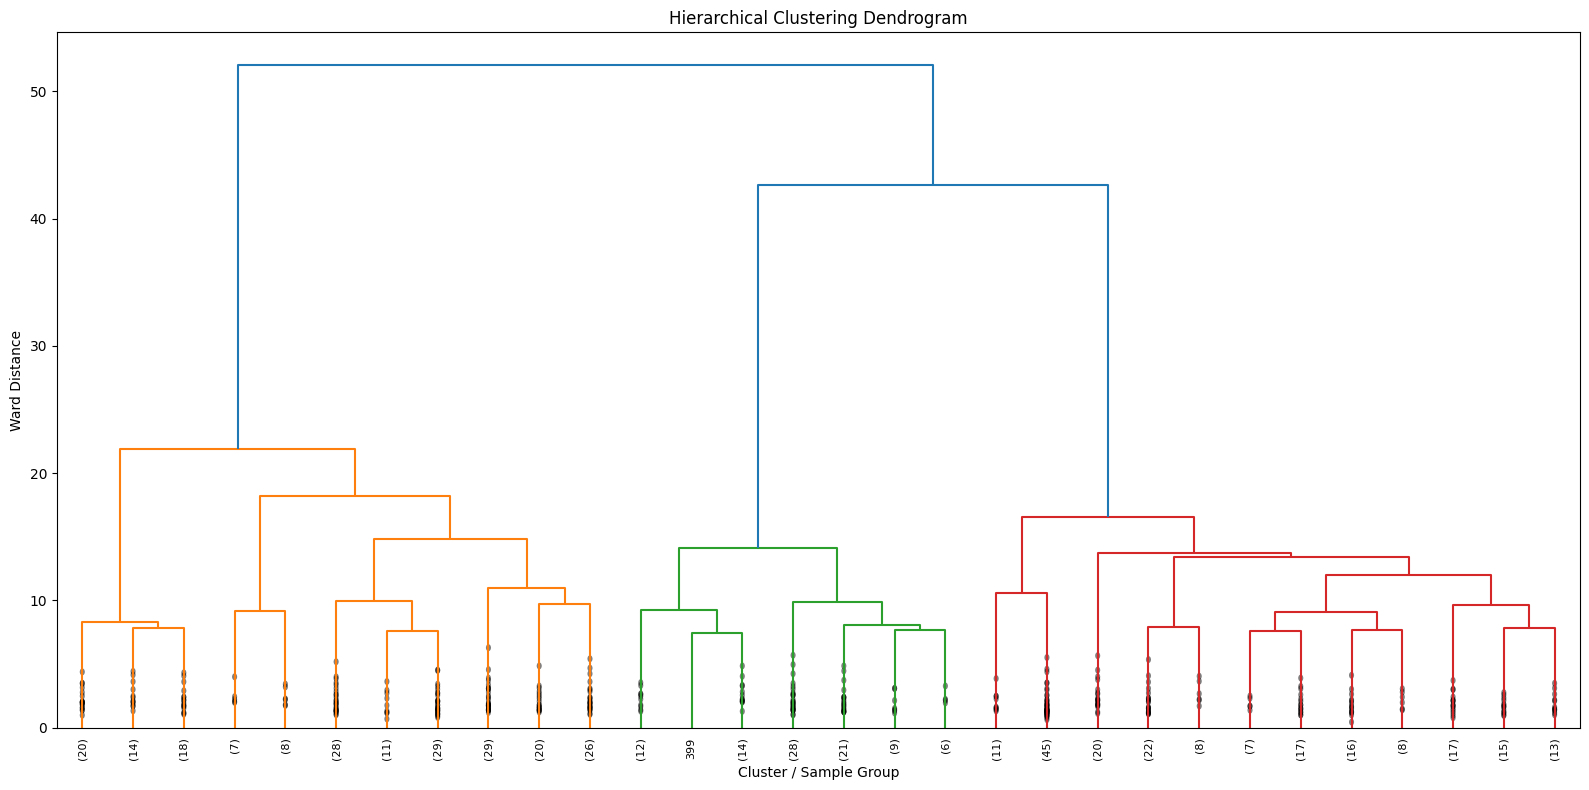

In [75]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np


# Use a sample for the dendrogram.
# A dendrogram for all 10,000 customers would be unnecessarily expensive.
sample_size = 500

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    X_pca.shape[0],
    size=sample_size,
    replace=False
)

X_pca_sample = X_pca[sample_indices]


# Hierarchical linkage
Z = linkage(
    X_pca_sample,
    method="ward"
)


# Plot dendrogram
plt.figure(figsize=(16, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Ward Distance")

plt.tight_layout()

plt.show()

In [76]:
import joblib

joblib.dump(
    Z,
    "../models/hierarchical_linkage.pkl"
)

print("Hierarchical linkage matrix saved.")

Hierarchical linkage matrix saved.
